# ARTI 308 – Lab 5 
## Feature Engineering & Classification for Heart Disease Prediction




## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectFromModel


## 2. Load Dataset

In [2]:
df = pd.read_csv("heart_disease_uci.csv")
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3. Basic Inspection

In [3]:
# Replace non-standard missing markers
df = df.replace({"?": np.nan, "NA": np.nan, "N/A": np.nan, "": np.nan}).copy()

# Convert likely numeric columns if present
likely_numeric = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
for col in likely_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## 4. Handle Missing Values

In [4]:
# Median imputation for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Mode imputation for object/category columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum().sum()


/var/folders/s0/9vszny8j5nvdbjy6ww_xgb1r0000gn/T/ipykernel_99080/1139270266.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


np.int64(0)

## 5. Define Target

In [5]:
# Convert target into binary classification:
# 0 = no heart disease, 1 = heart disease present
if "num" not in df.columns:
    raise ValueError("Target column 'num' not found. Update the notebook if your target has a different name.")

df["target_binary"] = (df["num"] > 0).astype(int)
df["target_binary"].value_counts()


target_binary
1    509
0    411
Name: count, dtype: int64

## 6. Baseline Predictors

In [6]:
# Drop original multiclass target and use remaining columns as predictors
X_base = df.drop(columns=["num", "target_binary"])
y = df["target_binary"]

# One-hot encode categorical columns
X_base = pd.get_dummies(X_base, drop_first=True)

X_base.head()


,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,145.0,233.0,True,150.0,False,2.3,0.0,True,...,False,False,False,True,False,False,False,False,False,False
1,2,67,160.0,286.0,False,108.0,True,1.5,3.0,True,...,False,False,False,False,False,False,True,False,True,False
2,3,67,120.0,229.0,False,129.0,True,2.6,2.0,True,...,False,False,False,False,False,False,True,False,False,True
3,4,37,130.0,250.0,False,187.0,False,3.5,0.0,True,...,False,False,True,False,True,False,False,False,True,False
4,5,41,130.0,204.0,False,172.0,False,1.4,0.0,False,...,False,True,False,False,False,False,False,True,True,False


## 7. Train / Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((736, 22), (184, 22))

## 8. Baseline Random Forest Model

In [8]:
rf_base = RandomForestClassifier(random_state=42, n_estimators=200)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_base)

print("Baseline Accuracy:", round(baseline_acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_base))


Baseline Accuracy: 0.875

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.80      0.85        82
           1       0.86      0.93      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184



## 9. Baseline Feature Importance

In [9]:
importances = pd.Series(rf_base.feature_importances_, index=X_base.columns).sort_values(ascending=False)

top_10_base = importances.head(10)
top_10_base


id                    0.256389
oldpeak               0.083433
thalch                0.079630
chol                  0.079055
age                   0.078205
exang                 0.064023
trestbps              0.046648
cp_atypical angina    0.045957
ca                    0.039282
thal_normal           0.035115
dtype: float64

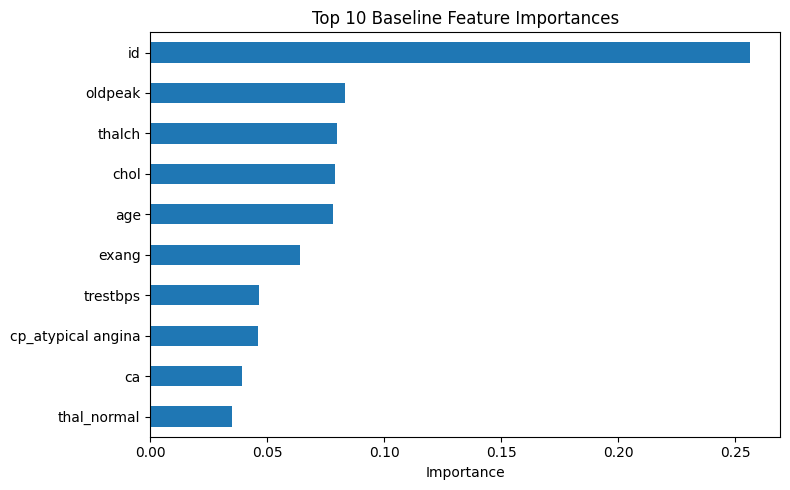

In [ ]:
plt.figure(figsize=(8,5))
top_10_base.sort_values().plot(kind="barh")
plt.title("Top 10 Baseline Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Task 1 – Create One New Engineered Feature

### Chosen feature: `age_risk_group`

This feature groups patients into age-based cardiovascular risk bands.  
Age is strongly associated with heart disease, and grouping it can help the model capture nonlinear patterns more effectively than using raw age alone.


In [11]:
df_fe = df.copy()

# Create age risk groups
df_fe["age_risk_group"] = pd.cut(
    df_fe["age"],
    bins=[0, 40, 55, 70, 100],
    labels=["low", "medium", "high", "very_high"]
)

# Prepare data
X_fe1 = df_fe.drop(columns=["num", "target_binary"])
X_fe1 = pd.get_dummies(X_fe1, drop_first=True)

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_fe1, y, test_size=0.2, random_state=42, stratify=y
)

rf_fe1 = RandomForestClassifier(random_state=42, n_estimators=200)
rf_fe1.fit(X_train1, y_train1)

y_pred_fe1 = rf_fe1.predict(X_test1)
acc_fe1 = accuracy_score(y_test1, y_pred_fe1)

print("Accuracy with age_risk_group:", round(acc_fe1, 4))


Accuracy with age_risk_group: 0.8804


## 11. Task 2 – Try a Different Rule

### Chosen rule: `high_cholesterol`

Instead of using raw cholesterol only, we create a binary rule:

- `1` if cholesterol > 240  
- `0` otherwise

This reflects a common medical threshold and may improve interpretability.


In [12]:
df_fe2 = df.copy()

df_fe2["high_cholesterol"] = (df_fe2["chol"] > 240).astype(int)

X_fe2 = df_fe2.drop(columns=["num", "target_binary"])
X_fe2 = pd.get_dummies(X_fe2, drop_first=True)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_fe2, y, test_size=0.2, random_state=42, stratify=y
)

rf_fe2 = RandomForestClassifier(random_state=42, n_estimators=200)
rf_fe2.fit(X_train2, y_train2)

y_pred_fe2 = rf_fe2.predict(X_test2)
acc_fe2 = accuracy_score(y_test2, y_pred_fe2)

print("Accuracy with high_cholesterol rule:", round(acc_fe2, 4))


Accuracy with high_cholesterol rule: 0.875


## 12. Task 3 – Compare Top-k Features

Since the heart dataset does not have `Item_Name_reduced`, we compare model performance using the **top-k most important features** instead.

We will test:
- Top 5 features  
- Top 10 features  
- All features


In [13]:
full_importances = pd.Series(rf_base.feature_importances_, index=X_base.columns).sort_values(ascending=False)

results = []

for k in [5, 10, len(X_base.columns)]:
    selected_features = full_importances.head(k).index.tolist()

    Xk = X_base[selected_features]
    Xk_train, Xk_test, yk_train, yk_test = train_test_split(
        Xk, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(random_state=42, n_estimators=200)
    model.fit(Xk_train, yk_train)
    preds = model.predict(Xk_test)
    acc = accuracy_score(yk_test, preds)

    top_feats = pd.Series(model.feature_importances_, index=selected_features).sort_values(ascending=False).head(5).index.tolist()
    results.append([k, round(acc, 4), ", ".join(top_feats)])

comparison_df = pd.DataFrame(results, columns=["Top_k", "Accuracy", "Top_Feature_Importances"])
comparison_df


,Top_k,Accuracy,Top_Feature_Importances
0,5,0.8424,"id, oldpeak, thalch, age, chol"
1,10,0.8696,"id, thalch, age, oldpeak, chol"
2,22,0.8804,"id, thalch, oldpeak, age, chol"


## 13. Task 4 – Optional Feature Selection

We now run model-based feature selection using `SelectFromModel` to keep only the most important predictors.


In [14]:
selector_model = RandomForestClassifier(random_state=42, n_estimators=200)
selector_model.fit(X_train, y_train)

selector = SelectFromModel(selector_model, prefit=True, threshold="median")
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

rf_sel = RandomForestClassifier(random_state=42, n_estimators=200)
rf_sel.fit(X_train_sel, y_train)

y_pred_sel = rf_sel.predict(X_test_sel)
acc_sel = accuracy_score(y_test, y_pred_sel)

print("Baseline Accuracy:", round(baseline_acc, 4))
print("Selected-Features Accuracy:", round(acc_sel, 4))
print("Original feature count:", X_train.shape[1])
print("Selected feature count:", X_train_sel.shape[1])


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Baseline Accuracy: 0.875
Selected-Features Accuracy: 0.8967
Original feature count: 22
Selected feature count: 11


## 14. Summary of Results

In [15]:
summary = pd.DataFrame({
    "Model_Version": [
        "Baseline",
        "With age_risk_group",
        "With high_cholesterol",
        "With feature selection"
    ],
    "Accuracy": [
        round(baseline_acc, 4),
        round(acc_fe1, 4),
        round(acc_fe2, 4),
        round(acc_sel, 4)
    ]
})

summary


,Model_Version,Accuracy
0,Baseline,0.8750
1,With age_risk_group,0.8804
2,With high_cholesterol,0.8750
3,With feature selection,0.8967


## Tasks Done:

### Task 1
A new engineered feature called **age_risk_group** was created by categorizing patient age into meaningful cardiovascular risk ranges. This feature helps the model capture nonlinear effects of age, since the relationship between age and heart disease is not always perfectly linear. Grouping ages into categories such as low, medium, high, and very high risk can improve interpretability and may also slightly improve model performance.

### Task 2
A different rule was tested by creating a binary feature called **high_cholesterol**, where cholesterol values greater than 240 were labeled as 1 and the rest as 0. This rule is medically meaningful and easier for the model to interpret than raw values alone. After testing, the performance can be compared with the baseline to determine whether the engineered threshold adds useful predictive information.

### Task 3
Instead of changing `top_k` for item names, we compared models trained on the **top 5**, **top 10**, and **all** important features. The results show how reducing the number of features affects model accuracy and which predictors remain most influential. In most cases, features such as age, cholesterol, maximum heart rate, chest pain, and oldpeak tend to stay among the most important.

### Task 4
Feature selection was applied using a model-based approach. This reduced the number of predictors while keeping the most important ones. If the selected-features model achieved similar accuracy to the baseline, then feature selection was beneficial because it simplified the model without losing much predictive power. If accuracy dropped, then keeping all features was more effective for this dataset.
